# Team 8 Notebook 1: Data + EDA

This notebook is for **Exploratory Data Analysis**.

## Responsibilities
- Describe the dataset: source, what it represents, and type of data
- Break down variables: predictors, target, identifiers, derived fields
- Run EDA: distributions, correlations, imbalance checks, patterns
- Identify data issues: missingness, outliers, duplicates, invalid values, type mismatches
- Create 3 to 5 clean visuals with labels and titles
- Draft the **Data Summary + EDA** section for the capstone article

Replace file paths, column names, and placeholder text once the dataset arrives.

In [49]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    RDKIT_AVAILABLE = True
except Exception:
    RDKIT_AVAILABLE = False
    print("RDKit not available. Chemistry-specific cells may need to be skipped.")

## 1. Dataset metadata

In [2]:
dataset_notes = {
    "dataset_name": "Cleaned J05 Antiviral Bioactivity Data",
    "source": "ChEMBL Database (via chembl_webresource_client)",
    "source_url": "https://www.ebi.ac.uk/chembl/",
    "what_it_represents": "Experimental bioactivity measurement data for molecules classified under the J05 (antivirals for systemic use) ATC code. Includes their chemical properties and activity against various targets.",
    "time_period": "All available compounds and bioactivity data up to the date of extraction (March 2026)",
    "unit_of_analysis": "Single molecule-assay interaction (with associated bioactivity measurements)",
    "data_type": "cross-sectional"
}
dataset_notes

{'dataset_name': 'Cleaned J05 Antiviral Bioactivity Data',
 'source': 'ChEMBL Database (via chembl_webresource_client)',
 'source_url': 'https://www.ebi.ac.uk/chembl/',
 'what_it_represents': 'Experimental bioactivity measurement data for molecules classified under the J05 (antivirals for systemic use) ATC code. Includes their chemical properties and activity against various targets.',
 'time_period': 'All available compounds and bioactivity data up to the date of extraction (March 2026)',
 'unit_of_analysis': 'Single molecule-assay interaction (with associated bioactivity measurements)',
 'data_type': 'cross-sectional'}

## 2. Load the dataset

In [3]:
DATA_PATH = "../data/clean_j05_antivirals.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (87, 24)


,chembl_id,pref_name,molecule_type,max_phase,therapeutic_flag,canonical_smiles,standard_inchi_key,full_mwt,alogp,hba,...,rdkit_valid,canonical_smiles_rdkit,mw_rdkit,logp_rdkit,hba_rdkit,hbd_rdkit,rotatable_bonds,tpsa,passes_mw_filter,passes_lipinski
0,CHEMBL57,NEVIRAPINE,Small molecule,4.0,True,Cc1ccnc2c1NC(=O)c1cccnc1N2C1CC1,NQDJXKOVJZTUJA-UHFFFAOYSA-N,266.30,2.65,4.0,...,True,Cc1ccnc2c1NC(=O)c1cccnc1N2C1CC1,266.304,2.65122,4,1,1,58.12,True,True
1,CHEMBL114,SAQUINAVIR,Small molecule,4.0,True,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,QWAXKHKRTORLEM-UGJKXSETSA-N,670.86,3.09,7.0,...,True,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,670.855,3.09240,7,5,12,166.75,True,False
2,CHEMBL584,NELFINAVIR,Small molecule,4.0,True,Cc1c(O)cccc1C(=O)N[C@@H](CSc1ccccc1)[C@H](O)CN...,QAGYKUNXZHXKMR-HKWSIXNMSA-N,567.80,4.75,6.0,...,True,Cc1c(O)cccc1C(=O)N[C@@H](CSc1ccccc1)[C@H](O)CN...,567.796,4.74762,6,4,9,101.90,True,False
3,CHEMBL116,AMPRENAVIR,Small molecule,4.0,True,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,YMARZQAQMVYCKC-OEMFJLHTSA-N,505.64,2.40,7.0,...,True,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,505.637,2.40280,7,3,11,131.19,True,False
4,CHEMBL593,DELAVIRDINE,Small molecule,4.0,True,CC(C)Nc1cccnc1N1CCN(C(=O)c2cc3cc(NS(C)(=O)=O)c...,WHBIGIKBNXZKFE-UHFFFAOYSA-N,456.57,2.72,6.0,...,True,CC(C)Nc1cccnc1N1CCN(C(=O)c2cc3cc(NS(C)(=O)=O)c...,456.572,2.71710,6,3,6,110.43,True,True


## 3. First look

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nPreview summary:")
display(df.describe(include="all").T.head(30))

Columns:
['chembl_id', 'pref_name', 'molecule_type', 'max_phase', 'therapeutic_flag', 'canonical_smiles', 'standard_inchi_key', 'full_mwt', 'alogp', 'hba', 'hbd', 'num_ro5_violations', 'synonyms', 'atc_codes', 'rdkit_valid', 'canonical_smiles_rdkit', 'mw_rdkit', 'logp_rdkit', 'hba_rdkit', 'hbd_rdkit', 'rotatable_bonds', 'tpsa', 'passes_mw_filter', 'passes_lipinski']

Data types:


,dtype
chembl_id,str
pref_name,str
molecule_type,str
max_phase,float64
therapeutic_flag,bool
canonical_smiles,str
standard_inchi_key,str
full_mwt,float64
alogp,float64
hba,float64



Preview summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
chembl_id,87,87,CHEMBL57,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pref_name,87,87,NEVIRAPINE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
molecule_type,87,2,Small molecule,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_phase,87.0,NaN,NaN,NaN,3.62069,0.702841,2.0,3.5,4.0,4.0,4.0
therapeutic_flag,87,2,True,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canonical_smiles,87,87,Cc1ccnc2c1NC(=O)c1cccnc1N2C1CC1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
standard_inchi_key,87,87,NQDJXKOVJZTUJA-UHFFFAOYSA-N,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_mwt,87.0,NaN,NaN,NaN,547.367011,654.833186,126.0,290.82,425.75,584.56,4667.0
alogp,85.0,NaN,NaN,NaN,1.970353,2.8142,-3.58,-0.5,2.31,4.07,8.12
hba,85.0,NaN,NaN,NaN,7.070588,2.658268,1.0,6.0,7.0,9.0,15.0


## 4. Variable breakdown

In [5]:
meanings = [
    "Unique ChEMBL compound identifier for the antiviral molecule.",
    "Generic market name of antiviral drug (if available).",
    "Type of moleule (e.g., small molecule, biologic).",
    "Highest clinical trial phase reached by the compound (I - IV).",
    "Boolean approved drug status - is it currently approved for use?",
    "Standardized text chemical structure representation of the molecule, used for computational analysis.",
    "A hashed version of the SMILES string, used for efficient storage and indexing.",
    "Molecular weight of the compound, which can influence its pharmacokinetics and bioactivity.",
    "Hydrophobicity/lipophilicity of the compound.",
    "Hydrogen bond acceptor count.",
    "Hydrogen bond donor count.",
    "Count of Lipinski's Rule of 5 violations.",
    "Synonym for the molecule, which may include alternative names or identifiers used in different contexts or databases.",
    "Anatomical Therapeutic Chemical classification.",
    "Boolean check if RDKit can process the molecule.", 
    "Cleaned version of the chemical SMILES string used for mathematical operations.", 
    "Standardized Molecular Weight: RDKit moleculear weight object created from the cleaned SMILES string, used for cheminformatics analyses.",
    "Calculated Partition Coefficient (LogP) using RDKit from the cleaned SMILES string, used for cheminformatics analyses.",
    "RDKit hydrogen bond acceptor object created from the cleaned SMILES string, used for cheminformatics analyses.",
    "RDKit hydrogen bond donor object created from the cleaned SMILES string, used for cheminformatics analyses.",
    "Rotatable bonds - single non-ring bonds, connected to non-terminal heavy atoms (non-hydrogen), allowing free rotation around their axis.",
    "Topological Polar Surface Area - sum of surfaces of polar atoms; influences drug transport properties such as absorption and permeability.",
    "Boolean: Is the molecule under 500 Daltons?",
    "Boolean: passes Lipinski's Rule of 5 (no more than 1 violation)?"
]

roles = [
    "Identifier",
    "Identifier",
    "Predictor",
    "Target",
    "Target",
    "Identifier",
    "Identifier",
    "Predictor",
    "Predictor",
    "Predictor",
    "Predictor",
    "Derived",
    "Identifier",
    "Identifier",
    "Predictor",
    "Identifier",
    "Predictor",
    "Predictor",
    "Predictor",
    "Predictor",
    "Predictor",
    "Predictor",
    "Derived",
    "Derived"
]
    
reasons = [
    "Unique key to link back to the ChEMBL database for additional information about the compound.",
    "Human-readable drug name that may be more familiar to researchers and practitioners.",
    "Categorizes the molecule type, which can influence its bioactivity and mechanism of action.",
    "Out of the various stages of drug development, the highest phase reached can indicate the molecule's potential and safety profile.",
    "Approved drugs have known safety and efficacy profiles, making this a critical variable for understanding which compounds are viable therapeutics.",
    "The 'source code' for the molecule, used to generate ML features.",
    "Allows for efficient storage and retrieval of chemical structure information without needing to process the full SMILES string.",
    "Molecular weight is a fundamental chemical property that can affect a compound's ability to interact with biological targets and its pharmacokinetic properties.",
    "Key descriptor of a compound's chemical properties, influencing its absorption, distribution, metabolism, excretion, and toxicity (ADMET) profile.",
    "H-bond acceptor count is an important descriptor that can influence a compound's solubility and its ability to interact with biological targets, affecting its bioactivity.",
    "H-bond donor count is another critical descriptor that can influence a compound's solubility and its ability to interact with biological targets, affecting its bioactivity.",
    "A derived variable that summarizes key drug-likeness properties, which can influence a compound's likelihood of being an orally active drug in humans.",
    "Provides additional names or identifiers for the molecule, which can be useful for cross-referencing with other databases or literature.",
    "Sanity check - all antivirals approved for human systemic use should beging with J05.",
    "Can RDKit successfully parse the SMILES string -- important for downstream cheminformatics analyses.",
    "Standardized SMILES string ensures consistency in chemical structure representation for computational analyses.",
    "Standardized molecular weight from RDKit. Affects a drug's ability to diffuse through cell membranes.",
    "Measures lipophilicity (how well the drug dissolves in fats vs water). Affects absorption and distribution.",
    "RDKit hydrogen bond acceptor used for sanity checks and downstream cheminformatics analyses.",
    "RDKit hydrogen bond donor used for sanity checks and downstream cheminformatics analyses.",
    "Quantitative descriptor for the conformational flexibility of a molecule. Play critical role in balancing molecular rigidity with flexibility for optimal binding to viral proteins (drug efficacy).",
    "Predicts cell membrane permeability and oral bioavailability, which are crucial for drug absorption and distribution in the body. High TPSA can indicate poor permeability, while low TPSA may suggest better absorption.",
    "Indicative of molecular size and efficacy - Molecules smaller than 500 Da generally penetrate the top layer of skin easily. Used as a common rule of thumb for drug-likeness, as larger molecules may have poor absorption and permeability.",
    "A widely used rule of thumb in drug discovery to evaluate the drug-likeness of a compound. Compounds that violate more than one of Lipinski's rules (molecular weight > 500 Da, LogP > 5, H-bond donors > 5, H-bond acceptors > 10) are less likely to be orally active drugs in humans."
]

variable_table = pd.DataFrame({
    "column_name": df.columns,
    "plain_language_meaning": meanings,
    "role": roles,
    "why_it_matters": reasons
})
variable_table

,column_name,plain_language_meaning,role,why_it_matters
0,chembl_id,Unique ChEMBL compound identifier for the anti...,Identifier,Unique key to link back to the ChEMBL database...
1,pref_name,Generic market name of antiviral drug (if avai...,Identifier,Human-readable drug name that may be more fami...
2,molecule_type,"Type of moleule (e.g., small molecule, biologic).",Predictor,"Categorizes the molecule type, which can influ..."
3,max_phase,Highest clinical trial phase reached by the co...,Target,"Out of the various stages of drug development,..."
4,therapeutic_flag,Boolean approved drug status - is it currently...,Target,Approved drugs have known safety and efficacy ...
5,canonical_smiles,Standardized text chemical structure represent...,Identifier,"The 'source code' for the molecule, used to ge..."
6,standard_inchi_key,"A hashed version of the SMILES string, used fo...",Identifier,Allows for efficient storage and retrieval of ...
7,full_mwt,"Molecular weight of the compound, which can in...",Predictor,Molecular weight is a fundamental chemical pro...
8,alogp,Hydrophobicity/lipophilicity of the compound.,Predictor,Key descriptor of a compound's chemical proper...
9,hba,Hydrogen bond acceptor count.,Predictor,H-bond acceptor count is an important descript...


In [52]:
# Check the distribution of therapeutic flag
print(df['therapeutic_flag'].value_counts())

# See the names of the actual therapeutic drugs
# print(df[df['therapeutic_flag'] == True]['pref_name'].unique())

therapeutic_flag
True     64
False    23
Name: count, dtype: int64


In [7]:
# Check the distribution of the max clinical trial phase variable
print(df['max_phase'].value_counts().sort_index())
print(df['max_phase'].value_counts(normalize=True).sort_index()*100)

# List names of drugs in each phase
for phase in sorted(df['max_phase'].dropna().unique()):
    drugs_in_phase = df[df['max_phase'] == phase]['pref_name'].unique()
    print(f"Phase {phase}: {len(drugs_in_phase)} drugs")
    print(drugs_in_phase)
    print("\n")

max_phase
2.0    11
3.0    11
4.0    65
Name: count, dtype: int64
max_phase
2.0    12.643678
3.0    12.643678
4.0    74.712644
Name: proportion, dtype: float64
Phase 2.0: 11 drugs
<StringArray>
[   'PLECONARIL',     'BRIVUDINE',      'TILORONE',      'FOSFONET',
   'LANINAMIVIR',    'MOROXYDINE',   'METHISAZONE',    'RAVIDASVIR',
  'TROMANTADINE', 'ELSULFAVIRINE',   'COBLOPASVIR']
Length: 11, dtype: str


Phase 3.0: 11 drugs
<StringArray>
[       'CLEVUDINE',       'UMIFENOVIR',      'FALDAPREVIR',
      'NARLAPREVIR', 'ENISAMIUM IODIDE',      'GRAZOPREVIR',
 'INOSINE PRANOBEX',      'ALBUVIRTIDE',     'MOLNUPIRAVIR',
      'ENSITRELVIR',        'INDINAVIR']
Length: 11, dtype: str


Phase 4.0: 65 drugs
<StringArray>
[           'NEVIRAPINE',            'SAQUINAVIR',            'NELFINAVIR',
            'AMPRENAVIR',           'DELAVIRDINE',            'ZIDOVUDINE',
             'FOSCARNET',            'LAMIVUDINE',           'IDOXURIDINE',
           'ZALCITABINE',           'FAMCICLOV

## 5. Missingness and duplicates

In [8]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

missing_table.head(25)

,missing_count,missing_pct,n_unique
num_ro5_violations,2,2.3,4
hbd,2,2.3,9
hba,2,2.3,13
alogp,2,2.3,80
chembl_id,0,0.0,87
pref_name,0,0.0,87
molecule_type,0,0.0,2
max_phase,0,0.0,3
full_mwt,0,0.0,87
standard_inchi_key,0,0.0,87


In [53]:
# Create a mask for rows with any missing values
missing_rows = df[df.isnull().any(axis=1)]

# Select identifying columns to see 'who' they are
cols_to_show = ['chembl_id', 'pref_name', 'molecule_type', 'alogp', 'hba', 'hbd']

print(f"Found {len(missing_rows)} compounds with missing data:")
display(missing_rows[cols_to_show])

Found 2 compounds with missing data:


,chembl_id,pref_name,molecule_type,alogp,hba,hbd
50,CHEMBL525076,ENFUVIRTIDE,Protein,NaN,NaN,NaN
76,CHEMBL4297257,ALBUVIRTIDE,Protein,NaN,NaN,NaN


In [9]:
dup_rows = df.duplicated().sum()
dup_pct = round((dup_rows / len(df)) * 100, 2)
print(f"Duplicate rows: {dup_rows} ({dup_pct}%)")

Duplicate rows: 0 (0.0%)


## 6. Optional: SMILES validity check

In [10]:
SMILES_COL = "canonical_smiles"

if RDKIT_AVAILABLE and SMILES_COL in df.columns:
    def is_valid_smiles(x):
        if pd.isna(x):
            return False
        try:
            return Chem.MolFromSmiles(str(x)) is not None
        except Exception:
            return False

    df["is_valid_smiles"] = df[SMILES_COL].apply(is_valid_smiles)
    validity = df["is_valid_smiles"].value_counts(dropna=False).to_frame("count")
    validity["pct"] = (validity["count"] / len(df) * 100).round(2)
    display(validity)
else:
    print("Skipping SMILES validity check.")

,count,pct
is_valid_smiles,,
True,87,100.0


In [12]:
if RDKIT_AVAILABLE and SMILES_COL in df.columns:
    def mol_from_smiles(x):
        try:
            return Chem.MolFromSmiles(str(x))
        except Exception:
            return None

    mols = df[SMILES_COL].apply(mol_from_smiles)
    df["mol_wt"] = mols.apply(lambda m: Descriptors.MolWt(m) if m else np.nan)
    df["logp"] = mols.apply(lambda m: Descriptors.MolLogP(m) if m else np.nan)
    df["h_donors"] = mols.apply(lambda m: Descriptors.NumHDonors(m) if m else np.nan)
    df["h_acceptors"] = mols.apply(lambda m: Descriptors.NumHAcceptors(m) if m else np.nan)
    df["tpsa"] = mols.apply(lambda m: Descriptors.TPSA(m) if m else np.nan)

    display(df[[c for c in ["mol_wt","logp","h_donors","h_acceptors","tpsa"] if c in df.columns]].describe().T)

,count,mean,std,min,25%,50%,75%,max
mol_wt,87.0,547.366874,654.833203,126.00400,290.81900,425.7540,584.55700,4666.998
logp,87.0,1.492277,4.031951,-19.00253,-0.58695,1.7749,4.04835,8.116
h_donors,87.0,4.275862,9.395310,0.00000,2.00000,3.0000,4.00000,65.000
h_acceptors,87.0,8.482759,8.855247,1.00000,6.00000,7.0000,9.00000,65.000
tpsa,87.0,171.832299,285.605442,26.02000,96.12500,125.3600,166.86500,2073.120


## 7. Univariate EDA

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols[:20])

Numeric columns: ['max_phase', 'full_mwt', 'alogp', 'hba', 'hbd', 'num_ro5_violations', 'mw_rdkit', 'logp_rdkit', 'hba_rdkit', 'hbd_rdkit', 'rotatable_bonds', 'tpsa', 'mol_wt', 'logp', 'h_donors', 'h_acceptors']
Categorical columns: ['chembl_id', 'pref_name', 'molecule_type', 'therapeutic_flag', 'canonical_smiles', 'standard_inchi_key', 'synonyms', 'atc_codes', 'rdkit_valid', 'canonical_smiles_rdkit', 'passes_mw_filter', 'passes_lipinski', 'is_valid_smiles']


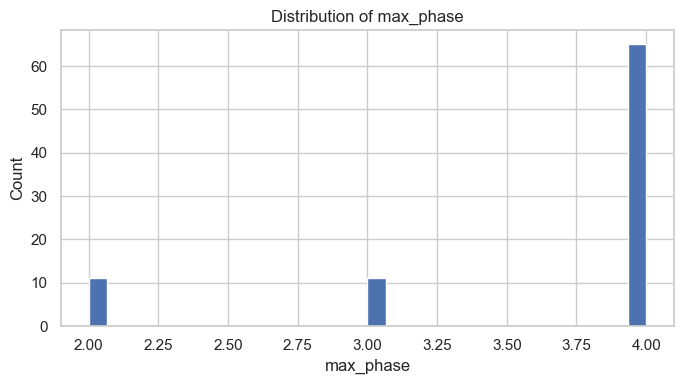

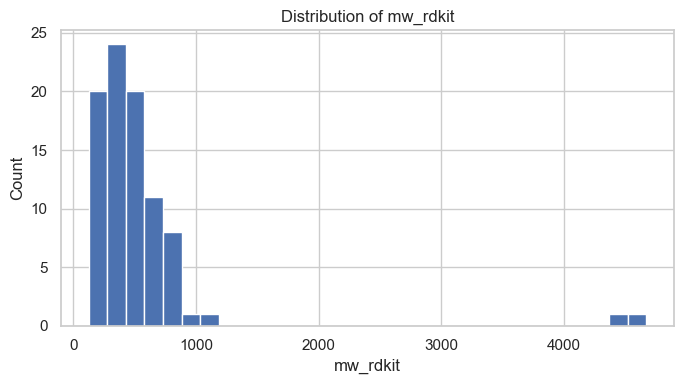

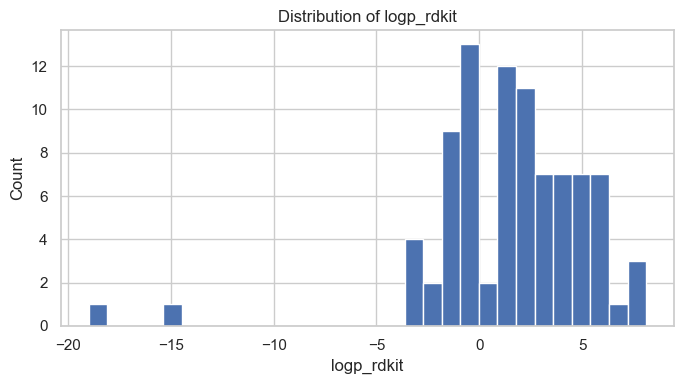

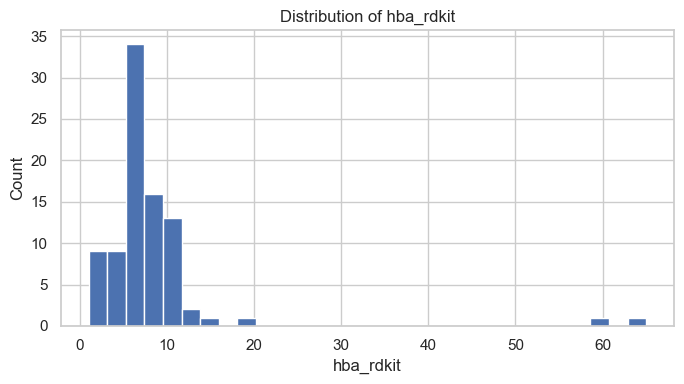

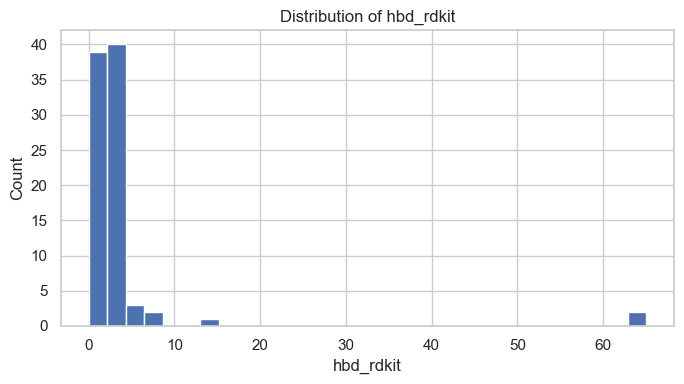

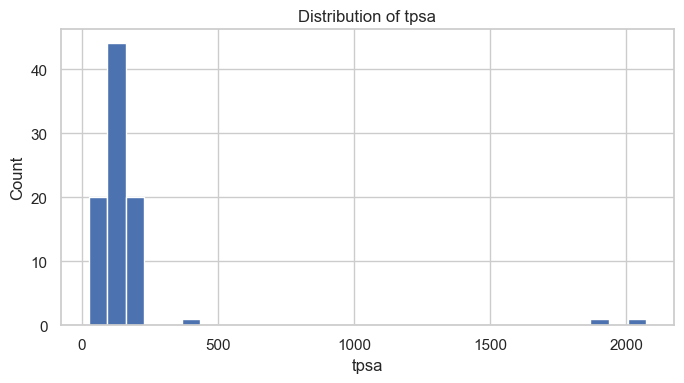

In [54]:
selected_numerical_cols = ['max_phase', 'mw_rdkit','logp_rdkit', 'hba_rdkit', 'hbd_rdkit', 'tpsa']
for col in selected_numerical_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

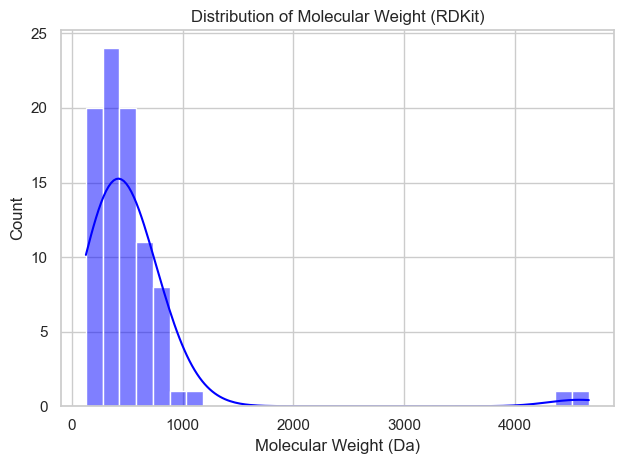

In [67]:
# Using Seaborn to make pretty plots of molecular weight and logP distributions
features_to_plot = ['mw_rdkit', 'logp_rdkit']
sns.set_theme(style="whitegrid")
sns.histplot(df['mw_rdkit'].dropna(), bins=30, kde=True, color='blue')
plt.title("Distribution of Molecular Weight (RDKit)")
plt.xlabel("Molecular Weight (Da)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()  


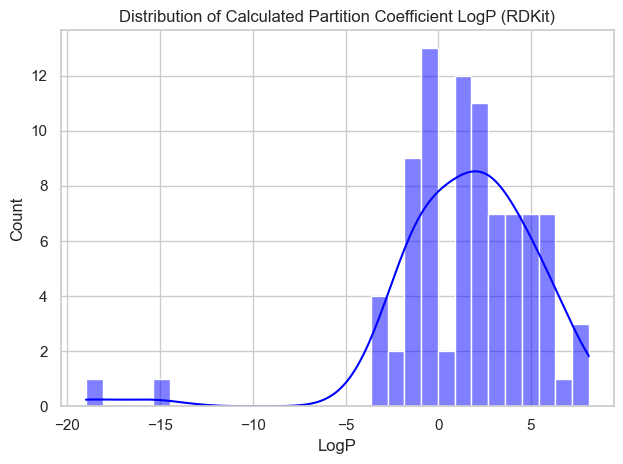

In [68]:
sns.histplot(df['logp_rdkit'].dropna(), bins=30, kde=True, color='blue')
plt.title("Distribution of Calculated Partition Coefficient LogP (RDKit)")
plt.xlabel("LogP")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

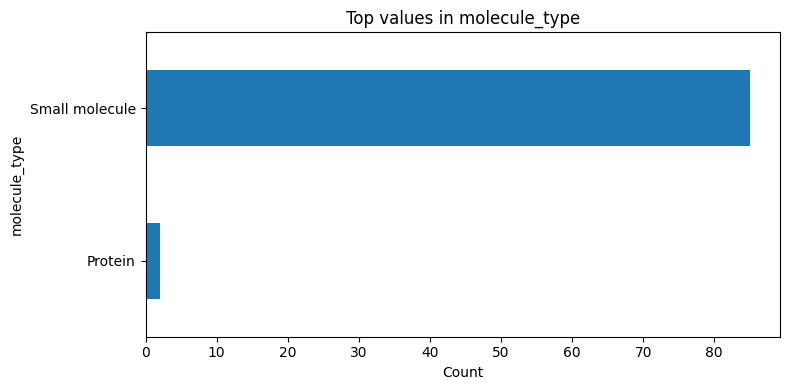

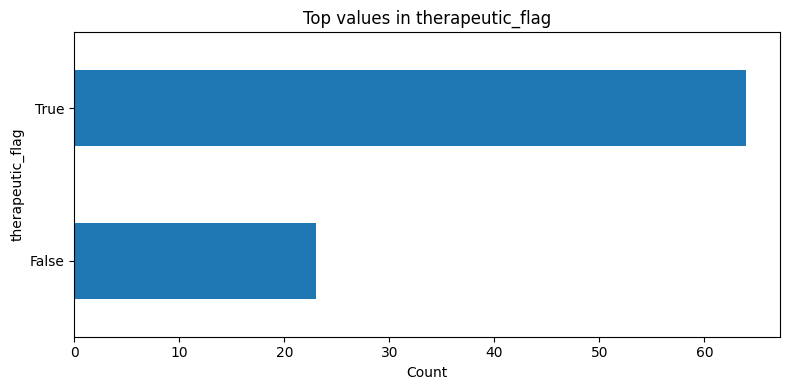

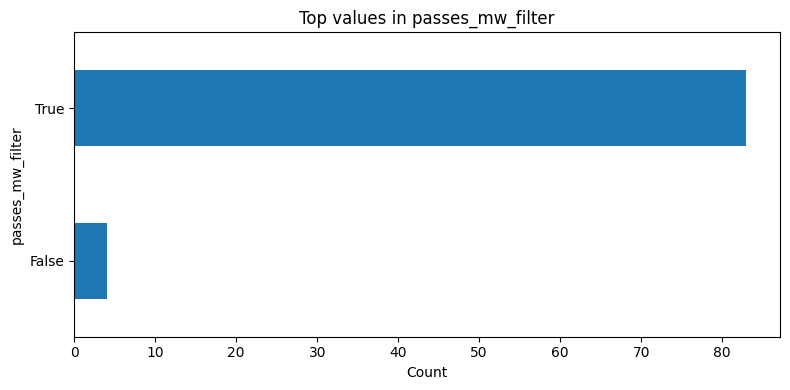

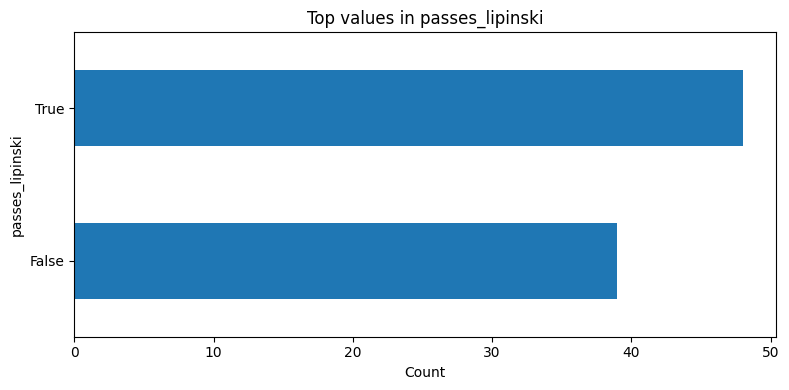

In [20]:
selected_categorical_cols = ['molecule_type', 'therapeutic_flag', 'passes_mw_filter', 'passes_lipinski']
for col in selected_categorical_cols:
    vc = df[col].astype(str).value_counts().head(15)
    plt.figure(figsize=(8, 4))
    vc.sort_values().plot(kind="barh")
    plt.title(f"Top values in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 8. Multivariate EDA

,max_phase,full_mwt,alogp,hba,hbd,num_ro5_violations,mw_rdkit,logp_rdkit,hba_rdkit,hbd_rdkit,rotatable_bonds,tpsa,mol_wt,logp,h_donors,h_acceptors
max_phase,1.00,-0.04,-0.03,0.20,-0.01,-0.05,-0.04,0.01,0.02,-0.04,-0.03,-0.02,-0.04,0.01,-0.04,0.02
full_mwt,-0.04,1.00,0.66,0.55,0.15,0.73,1.00,-0.53,0.96,0.95,0.98,0.97,1.00,-0.53,0.95,0.96
alogp,-0.03,0.66,1.00,0.18,-0.31,0.64,0.66,0.98,0.09,-0.34,0.52,-0.07,0.66,0.98,-0.34,0.09
hba,0.20,0.55,0.18,1.00,0.17,0.54,0.55,0.21,0.90,0.15,0.55,0.65,0.55,0.21,0.15,0.90
hbd,-0.01,0.15,-0.31,0.17,1.00,0.16,0.15,-0.29,0.19,0.85,0.24,0.58,0.15,-0.29,0.85,0.19
num_ro5_violations,-0.05,0.73,0.64,0.54,0.16,1.00,0.73,0.63,0.44,0.09,0.67,0.40,0.73,0.63,0.09,0.44
mw_rdkit,-0.04,1.00,0.66,0.55,0.15,0.73,1.00,-0.53,0.96,0.95,0.98,0.97,1.00,-0.53,0.95,0.96
logp_rdkit,0.01,-0.53,0.98,0.21,-0.29,0.63,-0.53,1.00,-0.63,-0.73,-0.63,-0.70,-0.53,1.00,-0.73,-0.63
hba_rdkit,0.02,0.96,0.09,0.90,0.19,0.44,0.96,-0.63,1.00,0.95,0.96,0.98,0.96,-0.63,0.95,1.00
hbd_rdkit,-0.04,0.95,-0.34,0.15,0.85,0.09,0.95,-0.73,0.95,1.00,0.97,0.99,0.95,-0.73,1.00,0.95


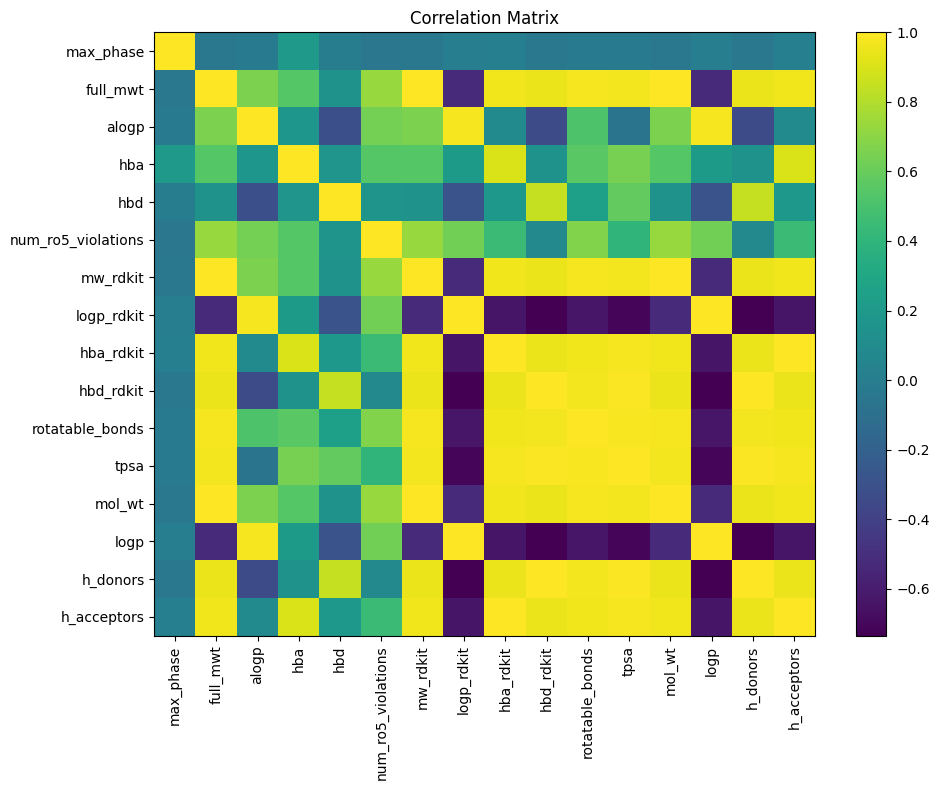

In [21]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    display(corr.round(2))

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

### Determining Most Effective Target Outcome:
- Clinical success of a molecule can be evaluated by therapeutic_flag (is it a drug on the market?) and max_phase (highest Phase reached in clinical trials)
- Whether or not a drug passes Lipinski's Rule of 5 is also an indicator of potential success.
- Are there molecules that reach Phase III or IV (high max_phase) but are never actually flagged as therapeutic? 
- If so, what chemical properties (e.g. mw_rdkit, logp) caused them to stall?
- Options for machine learning goals:
    1. Run separate but parallel models, each with one target variable. One model predicts if a molecule/drug will be approved for human use (therapeutic_flag), the other predicts how far it will move in clinical trials (max_phase).
    2. Combine multiple variables into one: A success score where a Phase IV drug is also therapeutically flagged (and passes Lipinski?) earns the highest score.

In [58]:
# Cross-tabulate the two variables to see how many molecules fall into each combination
success_matrix = pd.crosstab(df['passes_lipinski'], df['therapeutic_flag'])

print("Relationship between Lipinski Rule Compliance and Therapeutic Status:")
display(success_matrix)

Relationship between Lipinski Rule Compliance and Therapeutic Status:


therapeutic_flag,False,True
passes_lipinski,,
False,12,27
True,11,37


#### For now, choose "passes lipinski" as the target variable as it indicates a drug with potential in clinical trials.

In [55]:
GROUP_COL = "passes_lipinski"
VALUE_COL = "mw_rdkit"

if GROUP_COL in df.columns and VALUE_COL in df.columns:
    grouped = df.groupby(GROUP_COL)[VALUE_COL].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)
    display(grouped.head(20))
else:
    print("Update GROUP_COL and VALUE_COL if needed.")

,count,mean,median,std
passes_lipinski,,,,
True,48,312.741896,313.8145,95.331474
False,39,836.136077,602.6750,896.715587


In [56]:
GROUP_COL = "max_phase"
VALUE_COL = "mw_rdkit"

if GROUP_COL in df.columns and VALUE_COL in df.columns:
    grouped = df.groupby(GROUP_COL)[VALUE_COL].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)
    display(grouped.head(20))
else:
    print("Update GROUP_COL and VALUE_COL if needed.")

,count,mean,median,std
max_phase,,,,
4.0,65,498.748477,425.754,535.404748
2.0,11,406.583909,346.340,223.588448
3.0,11,975.440364,631.818,1250.757271


In [57]:
GROUP_COL = "therapeutic_flag"
VALUE_COL = "mw_rdkit"

if GROUP_COL in df.columns and VALUE_COL in df.columns:
    grouped = df.groupby(GROUP_COL)[VALUE_COL].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)
    display(grouped.head(20))
else:
    print("Update GROUP_COL and VALUE_COL if needed.")

,count,mean,median,std
therapeutic_flag,,,,
True,64,499.872078,422.569,537.678809
False,23,679.526304,477.424,907.495715


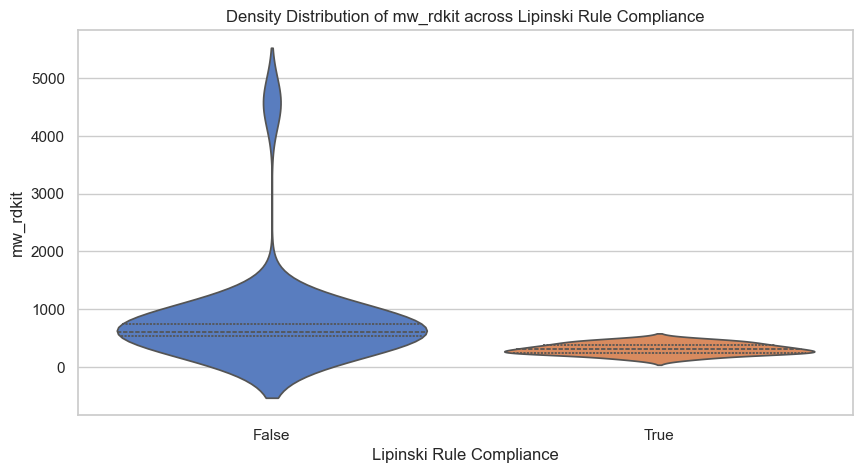

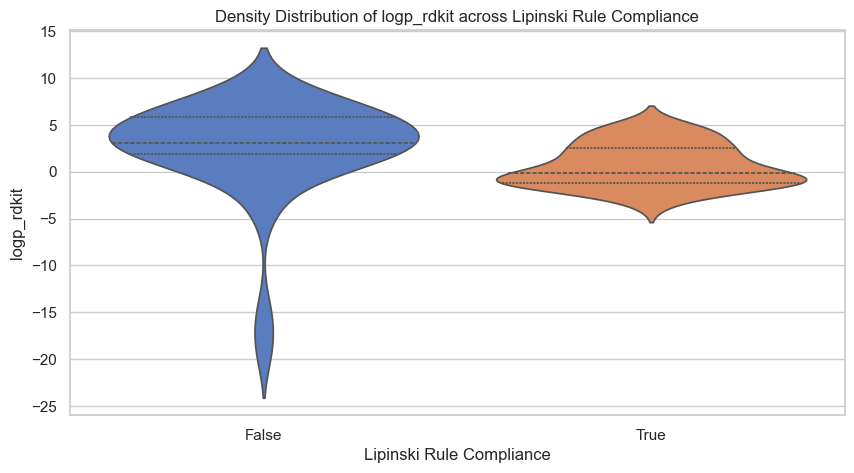

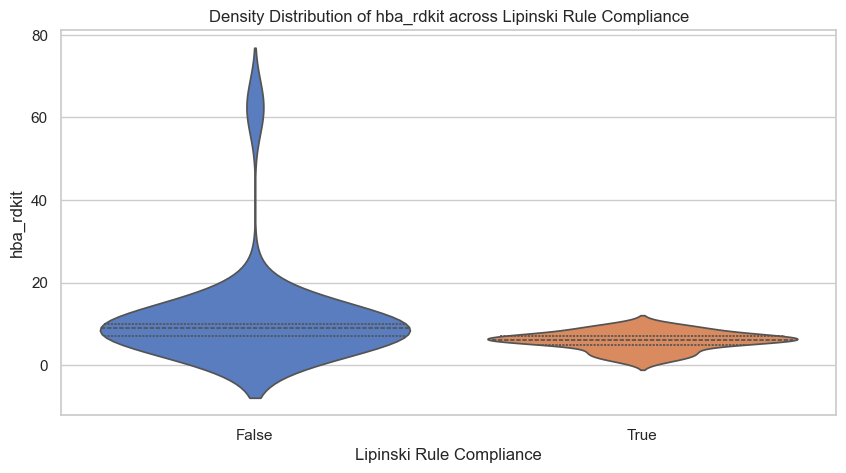

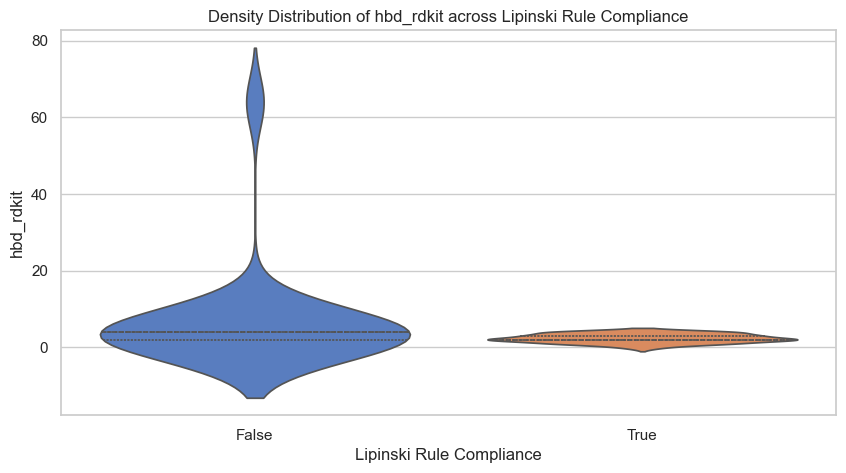

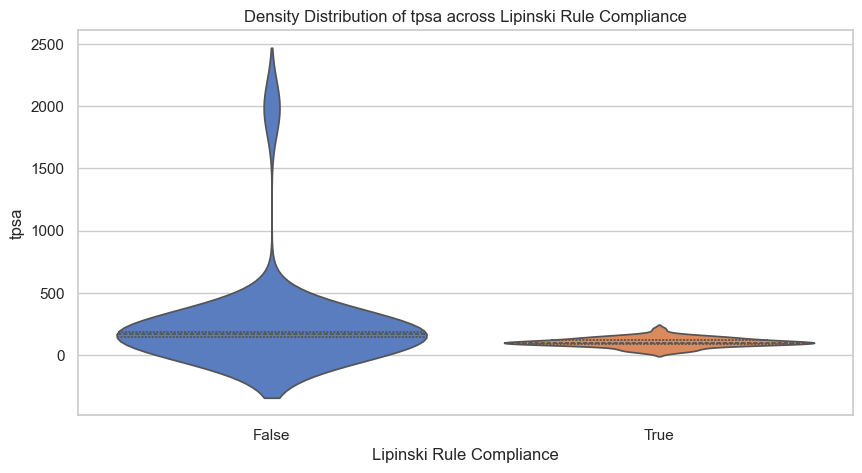

In [59]:
# Compare the distributions of RDKit descriptors for Clinical Trial Phase using violin plots

# Define  RDKit descriptors to analyze
rdkit_features = ['mw_rdkit', 'logp_rdkit', 'hba_rdkit', 'hbd_rdkit', 'tpsa']

# Set  visual style
sns.set_theme(style="whitegrid")

# Loop through and create the plots
for feature in rdkit_features:
    if feature in df.columns:
        plt.figure(figsize=(10, 5))
        
        # Create the violin plot
        # Use 'inner="quartile"' to show the dashed lines for the 25th, 50th, and 75th percentiles
        sns.violinplot(data=df, x='passes_lipinski', y=feature, palette='muted', inner="quartile")
        
        plt.title(f'Density Distribution of {feature} across Lipinski Rule Compliance')
        plt.xlabel('Lipinski Rule Compliance')
        plt.ylabel(feature)
        plt.show()
    else:
        print(f"Skipping {feature}: Column not found.")

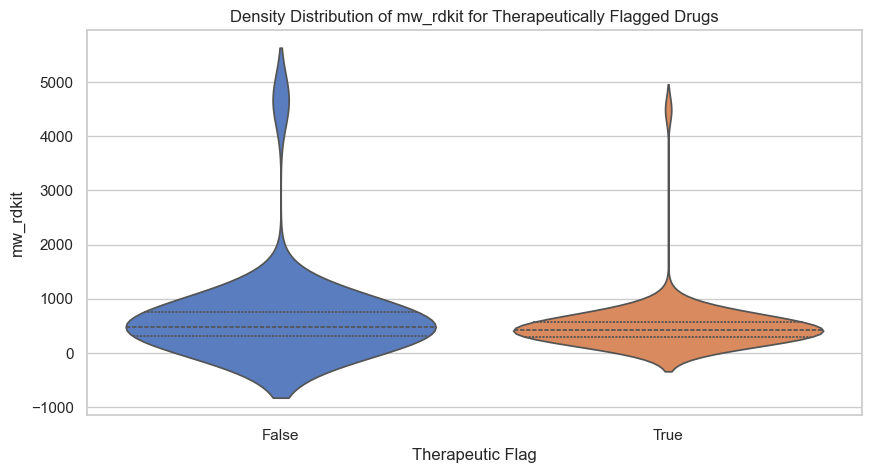

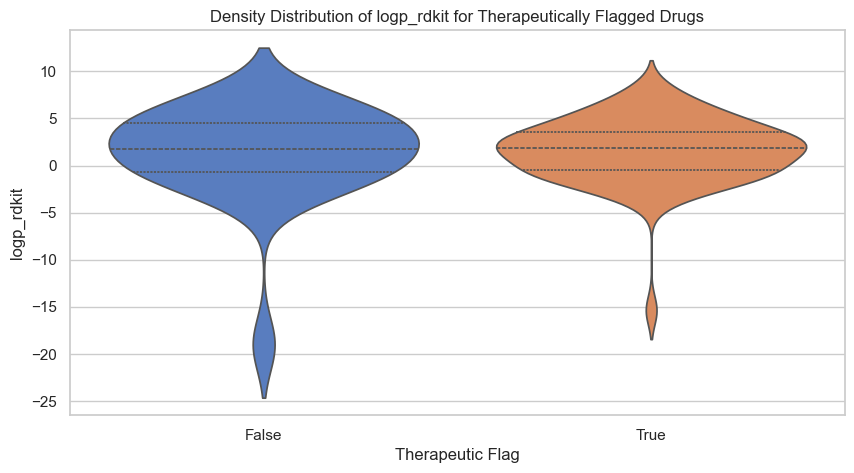

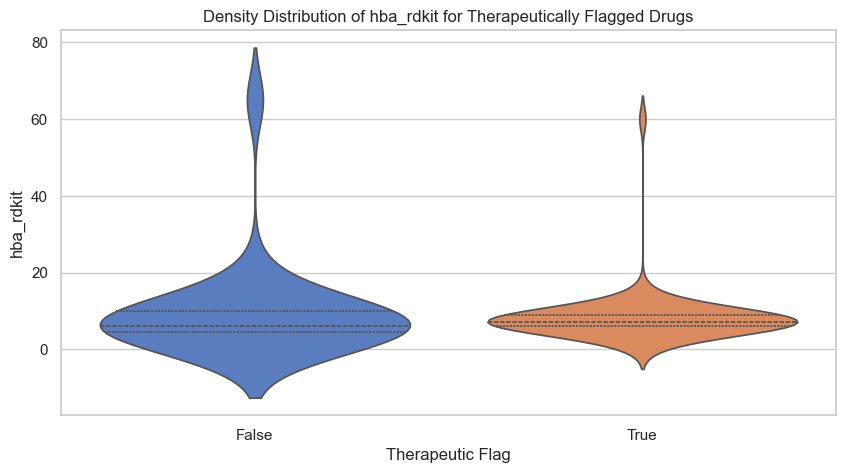

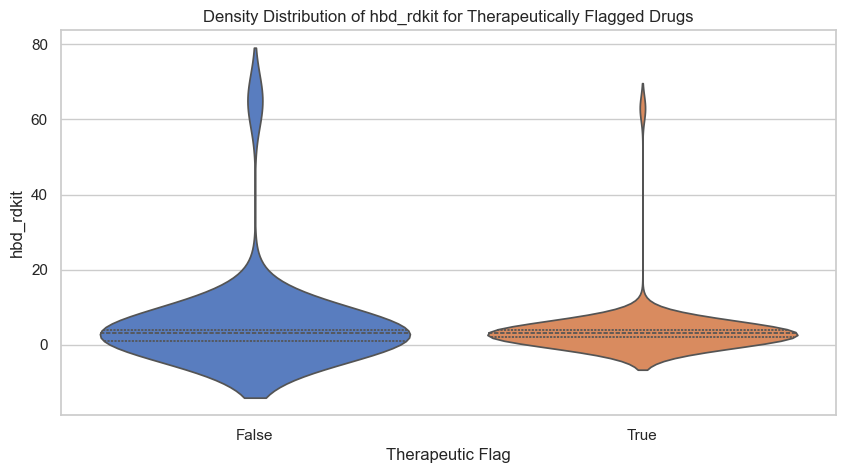

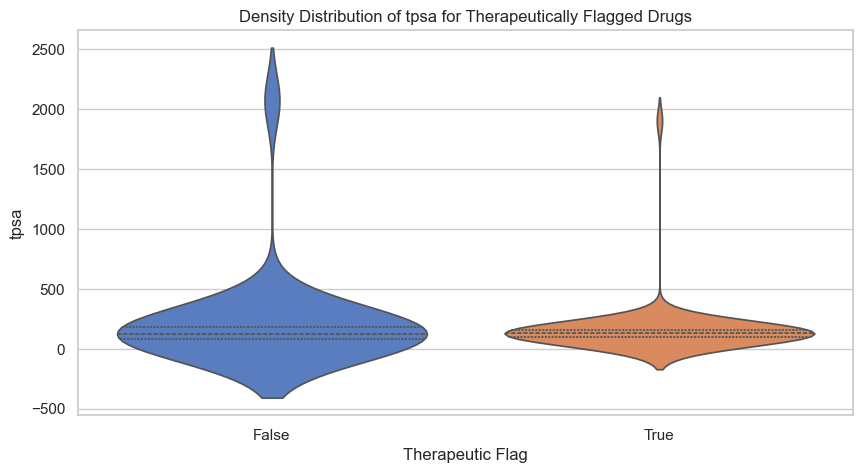

In [60]:
# Compare the distributions of RDKit descriptors for therapeutically flagged drugs using violin plots

# Define  RDKit descriptors to analyze
rdkit_features = ['mw_rdkit', 'logp_rdkit', 'hba_rdkit', 'hbd_rdkit', 'tpsa']

# Set  visual style
sns.set_theme(style="whitegrid")

# Loop through and create the plots
for feature in rdkit_features:
    if feature in df.columns:
        plt.figure(figsize=(10, 5))
        
        # Create the violin plot
        # Use 'inner="quartile"' to show the dashed lines for the 25th, 50th, and 75th percentiles
        sns.violinplot(data=df, x='therapeutic_flag', y=feature, palette='muted', inner="quartile")
        
        plt.title(f'Density Distribution of {feature} for Therapeutically Flagged Drugs')
        plt.xlabel('Therapeutic Flag')
        plt.ylabel(feature)
        plt.show()
    else:
        print(f"Skipping {feature}: Column not found.")

## 9. Outlier review

In [41]:
outlier_summary = []

for col in numeric_cols:
    s = df[col].dropna()
    if len(s) < 5:
        continue
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        "column": col,
        "outlier_count": int(outliers),
        "outlier_pct": round((outliers / len(s)) * 100, 2)
    })

pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False).head(20)

,column,outlier_count,outlier_pct
0,max_phase,11,12.64
8,hba_rdkit,6,6.90
15,h_acceptors,6,6.90
14,h_donors,4,4.60
9,hbd_rdkit,4,4.60
3,hba,3,3.53
1,full_mwt,3,3.45
6,mw_rdkit,3,3.45
11,tpsa,3,3.45
10,rotatable_bonds,3,3.45


In [48]:
# View the actual outlier values for the top variable with outliers
if outlier_summary:
    top_outlier_col = max(outlier_summary, key=lambda x: x["outlier_pct"])["column"]
    s = df[top_outlier_col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[top_outlier_col] < lower) | (df[top_outlier_col] > upper)][top_outlier_col]
    print(f"Outliers in {top_outlier_col}:")
    print(outliers.sort_values().unique())
else:
    print("No numeric columns to analyze for outliers.")

Outliers in max_phase:
[2.]


## 10. Save tables for the paper

In [42]:
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

missing_table.to_csv("outputs/tables/eda_missingness_table.csv")
variable_table.to_csv("outputs/tables/eda_variable_dictionary_template.csv", index=False)

print("Saved EDA tables to outputs/tables/")

Saved EDA tables to outputs/tables/


## 11. Draft the Data Summary + EDA section

In [61]:
eda_writeup_notes = [
    "The dataset contains 87 rows and 24 columns.",
    "The unit of analysis is SMILES strings of J05 (systemic antiviral) molecular compounds.",
    "The main predictors appear to be molecular weight, logP, and hydrogen bond donors and acceptors (as measures of lipophilicity/hydrophobicity/solubility).",
    "The main data quality issues were outliers in the molecular weight distribution.",
    "Key EDA findings included key insights about the relationship between Lipinski rule compliance and therapeutic status.",
    "These findings matter for the project because they inform decisions about which molecular characteristics to prioritize for lead optimization and faster, more effective drug development."
]

for note in eda_writeup_notes:
    print("-", note)

- The dataset contains 87 rows and 24 columns.
- The unit of analysis is SMILES strings of J05 (systemic antiviral) molecular compounds.
- The main predictors appear to be molecular weight, logP, and hydrogen bond donors and acceptors (as measures of lipophilicity/hydrophobicity/solubility).
- The main data quality issues were outliers in the molecular weight distribution.
- Key EDA findings included key insights about the relationship between Lipinski rule compliance and therapeutic status.
- These findings matter for the project because they inform decisions about which molecular characteristics to prioritize for lead optimization and faster, more effective drug development.
